# 01 - Download + pool NHANES FibroScan cycles (LSM + CAP)

Pull the SAS XPT files for both NHANES transient-elastography cycles, keep the
variables this analysis needs -- now including **CAP** (controlled attenuation
parameter, hepatic steatosis) alongside **LSM** (liver stiffness, fibrosis) --
and write one tidy **pooled** parquet for the notebooks that follow.

## Why pool two cycles

FibroScan first appears in NHANES in the **2017 - March 2020 pre-pandemic
combined release (`P_LUX`)**, whose examination weight is `WTMECPRP`. A second
cycle, **2021 - August 2023 (`LUX_L`)**, uses the standard `WTMEC2YR`. Notebooks
01-05 previously used `P_LUX` alone; pooling `LUX_L` in roughly **doubles** the
sample (from ~7.8k to ~13k+ valid FibroScan adults; the 80+ band grows from ~410
to ~670), which tightens every per-(sex, age) estimate.

We pool with each cycle's MEC weight **halved** (`MEC_WT * 0.5`) -- the standard
NCHS multi-cycle practice, validated against a colleague's table in notebook 06.
NCHS publishes no official recipe for combining the special pre-pandemic file
with later 2-year cycles, so this is a reasonable, documented approximation.

## Variables kept (both cycles)

- `SEQN` - respondent id (join key)
- `RIAGENDR` -> `sex`; `RIDAGEYR` -> `age_years` (**top-coded at 80 = 80+**)
- MEC weight (`WTMECPRP` for P_LUX, `WTMEC2YR` for LUX_L) -> `MEC_WT`; pooled
  weight `MEC_WT_POOL = MEC_WT * 0.5`
- `SDMVPSU`, `SDMVSTRA` - masked variance pseudo-PSU and stratum
- `LUXSMED` -> `LSM_KPA`, `LUXSIQR` -> `LSM_IQR` (median liver stiffness + IQR)
- `LUXCAPM` -> `CAP_DBM`, `LUXCPIQR` -> `CAP_IQR` (median CAP + IQR)
- `LUAXSTAT` -> `exam_complete` (`1` = complete exam; we keep only complete exams)

All parse/pool logic lives in `lsm_cap_fit.py` (`build_pooled`, `analysis_frame`)
so every notebook filters identically.


In [1]:
import os, urllib.request
from pathlib import Path
import numpy as np, pandas as pd
import lsm_cap_fit as L

# Source XPTs (cached under data/raw/nhanes/... ; downloaded only if missing).
SRC = {
    L.RAW_P / 'P_DEMO.xpt': 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DEMO.xpt',
    L.RAW_P / 'P_LUX.xpt':  'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_LUX.xpt',
    L.RAW_L / 'DEMO_L.xpt': 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.xpt',
    L.RAW_L / 'LUX_L.xpt':  'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/LUX_L.xpt',
}
for out, url in SRC.items():
    out.parent.mkdir(parents=True, exist_ok=True)
    if out.exists():
        print(f'cached: {out.name} ({out.stat().st_size:,} bytes)')
        continue
    print(f'downloading {url} -> {out}')
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=120) as r:
        out.write_bytes(r.read())
    print(f'  saved {out.stat().st_size:,} bytes')


cached: P_DEMO.xpt (3,614,720 bytes)
cached: P_LUX.xpt (1,105,920 bytes)
cached: DEMO_L.xpt (2,582,160 bytes)
cached: LUX_L.xpt (765,680 bytes)


## Parse and pool

`lsm_cap_fit.build_pooled()` reads both DEMO+LUX pairs, harmonises the weight
column, tags each row with its `cycle`, concatenates, and adds the halved pooled
weight `MEC_WT_POOL`.


In [2]:
pool = L.build_pooled()
print(f'pooled rows (all ages, both cycles): {len(pool):,}')
print(pool.groupby('cycle').size().to_string())
pool.head()


pooled rows (all ages, both cycles): 27,493
cycle
2017_2020    15560
2021_2023    11933


,SEQN,cycle,sex,age_years,MEC_WT,SDMVPSU,SDMVSTRA,LSM_KPA,LSM_IQR,CAP_DBM,CAP_IQR,exam_complete,MEC_WT_POOL
0,109263,2017_2020,Male,2.0,8.951816e+03,3,156,NaN,NaN,NaN,NaN,False,4.475908e+03
1,109264,2017_2020,Female,13.0,1.227116e+04,1,155,NaN,NaN,NaN,NaN,False,6.135579e+03
2,109265,2017_2020,Male,2.0,1.665876e+04,1,157,NaN,NaN,NaN,NaN,False,8.329382e+03
3,109266,2017_2020,Female,29.0,8.154968e+03,2,168,6.4,1.0,277.0,45.0,True,4.077484e+03
4,109267,2017_2020,Female,21.0,5.397605e-79,1,156,NaN,NaN,NaN,NaN,False,2.698803e-79


## Sample-size audit: what pooling buys us

Valid FibroScan record = complete exam (`exam_complete`), positive MEC weight,
and a non-missing measurement. The per-cycle and pooled counts below show the
2021-2023 cycle roughly doubling the analytic sample, especially in the older
bands the trial enrols.


In [3]:
ana = L.analysis_frame(pool, variable='both')   # valid LSM *and* CAP
adults = ana[ana['age_years'] >= 18]
print('Valid FibroScan (LSM+CAP) records, complete exam, weight > 0:')
print(f'  all ages : {len(ana):,}')
print(f'  adults 18+: {len(adults):,}')
print()
print('By cycle (adults 18+):')
print(adults.groupby('cycle').size().to_string())
print()
print('Adults 18+ per fitted age band, P_LUX-only vs pooled:')
older = L.assign_band(adults[adults['age_years'] >= 60])
for lo, hi, lab in L.band_edges():
    cell = older[older['age_start'] == lo]
    p_only = (cell['cycle'] == '2017_2020').sum()
    print(f'  {lab:6}  P_LUX={p_only:4d}   pooled={len(cell):4d}   (+{len(cell) - p_only})')


Valid FibroScan (LSM+CAP) records, complete exam, weight > 0:
  all ages : 15,300
  adults 18+: 13,292

By cycle (adults 18+):
cycle
2017_2020    7767
2021_2023    5525

Adults 18+ per fitted age band, P_LUX-only vs pooled:
  60-64   P_LUX= 866   pooled=1538   (+672)
  65-69   P_LUX= 600   pooled=1216   (+616)
  70-74   P_LUX= 476   pooled= 978   (+502)
  75-79   P_LUX= 301   pooled= 606   (+305)
  80+     P_LUX= 410   pooled= 667   (+257)


## Distribution snapshots (weighted, adults 18+)

A first look at both variables on the pooled sample. LSM is heavily right-skewed
(a long fibrosis tail); CAP is roughly symmetric around ~250-280 dB/m. The dotted
lines mark the fibrosis-stage ladder (LSM 6/8/10/15 kPa) and the CAP steatosis
gate (288 dB/m).


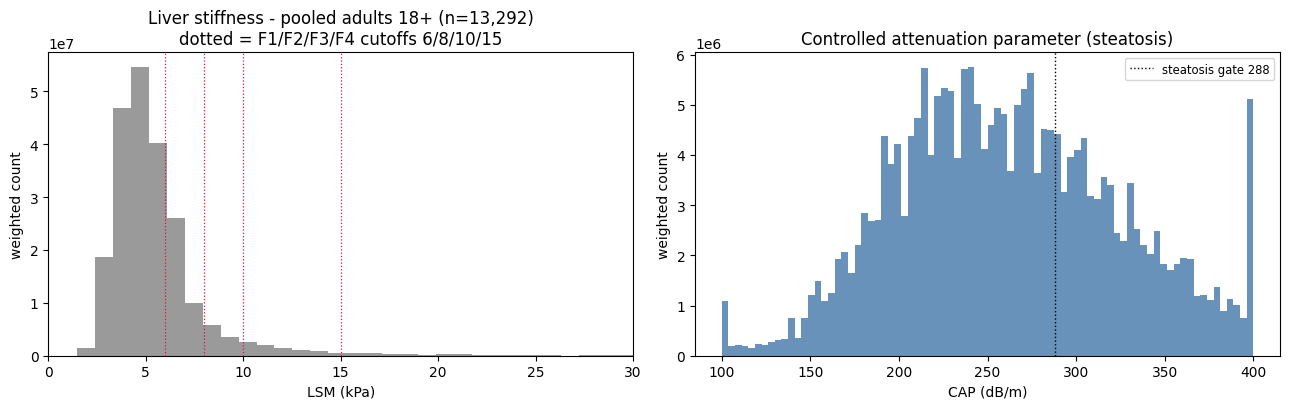

In [4]:
import matplotlib.pyplot as plt
w = adults['MEC_WT_POOL'].values
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.hist(adults['LSM_KPA'].values, bins=80, weights=w, color='#888', alpha=0.85)
for c in L.LSM_CUTOFFS:
    ax.axvline(c, color='crimson', linestyle=':', linewidth=0.9)
ax.set_xlim(0, 30)
ax.set_xlabel('LSM (kPa)'); ax.set_ylabel('weighted count')
ax.set_title(f'Liver stiffness - pooled adults 18+ (n={len(adults):,})\n'
             'dotted = F1/F2/F3/F4 cutoffs 6/8/10/15')

ax = axes[1]
ax.hist(adults['CAP_DBM'].dropna().values, bins=80,
        weights=adults.loc[adults['CAP_DBM'].notna(), 'MEC_WT_POOL'].values,
        color='#4477aa', alpha=0.8)
ax.axvline(L.CAP_STEATOSIS_GATE, color='black', linestyle=':', linewidth=1.0,
           label=f'steatosis gate {L.CAP_STEATOSIS_GATE:.0f}')
ax.set_xlabel('CAP (dB/m)'); ax.set_ylabel('weighted count')
ax.set_title('Controlled attenuation parameter (steatosis)')
ax.legend(fontsize='small')
fig.tight_layout(); plt.show()


## Save

Write the pooled frame (LSM + CAP + design variables) to
`data/derived/nhanes_p_lux_plus_l.parquet`, and keep a P_LUX-only parquet for
provenance / single-cycle comparisons.


In [5]:
L.DERIVED.mkdir(parents=True, exist_ok=True)
pool.to_parquet(L.POOLED_PARQUET, index=False)
print(f'wrote {L.POOLED_PARQUET} ({L.POOLED_PARQUET.stat().st_size:,} bytes)')

p_only = pool[pool['cycle'] == '2017_2020'].copy()
p_path = L.DERIVED / 'nhanes_p_lux.parquet'
p_only.to_parquet(p_path, index=False)
print(f'wrote {p_path} ({p_path.stat().st_size:,} bytes)')
print()
print('pooled columns:', list(pool.columns))


wrote /mnt/share/homes/abie/projects/2026/ai_assisted_us_health_data_analysis/data/derived/nhanes_p_lux_plus_l.parquet (758,909 bytes)
wrote /mnt/share/homes/abie/projects/2026/ai_assisted_us_health_data_analysis/data/derived/nhanes_p_lux.parquet (447,544 bytes)

pooled columns: ['SEQN', 'cycle', 'sex', 'age_years', 'MEC_WT', 'SDMVPSU', 'SDMVSTRA', 'LSM_KPA', 'LSM_IQR', 'CAP_DBM', 'CAP_IQR', 'exam_complete', 'MEC_WT_POOL']
